# A.2 Reference design — Two coupled transmons

Two transmons, each with its own multiplexed readout resonator, joined by a meandered coplanar-waveguide coupling bus — the building block of a two-qubit gate.

> **Reference design — attribution.** Adapted, with attribution, from the open-source [SQDMetal](https://github.com/sqdlab/SQDMetal) project (Apache-2.0) and its benchmark devices in D. Sommers, P. Pakkiam, Z. Degnan, C.-C. Chiu, D. Gautam, Y.-H. Chen, and A. Fedorov, *"Open-Source Highly Parallel Electromagnetic Simulations for Superconducting Circuits,"* [arXiv:2511.01220](https://arxiv.org/abs/2511.01220) (2025). Re-implemented here with stock Quantum Metal components.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/qiskit-community/qiskit-metal/blob/main/docs/tut/full-design-examples/A.2-Two-coupled-transmons.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/qiskit-community/qiskit-metal/main?labpath=docs%2Ftut%2Ffull-design-examples%2FA.2-Two-coupled-transmons.ipynb)

> 💡 **Running in Colab or Binder?** Skip the desktop GUI install — the cell below grabs the lite (no-Qt) wheel, and `qm.gui(design)` auto-picks an inline matplotlib viewer with the same API as the desktop `MetalGUI`.

In [1]:
# In Colab / Binder, uncomment to install Quantum Metal (lite, no Qt).
# Locally you should already have it via `pip install quantum-metal` or
# `pip install 'quantum-metal[gui]'` for the desktop GUI.
# !pip install -q quantum-metal

In [2]:
import qiskit_metal as qm
from qiskit_metal import Dict, designs
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond

design = designs.DesignPlanar()
design.overwrite_enabled = True

# The default die is 9mm x 6mm; the launchpads below sit outside it.
design.chips.main.size.size_x = "14mm"
design.chips.main.size.size_y = "9mm"

09:27PM 19s INFO [_start_renderers]: Renderer=gmsh skipped: runtime dependency not installed (renderer_gmsh requires gmsh. Install with: pip install 'quantum-metal[mesh]' (or the legacy alias 'quantum-metal[fem]')).


In [3]:
def feed(a, ap, b, bp, name):
    """Auto-route a coplanar-waveguide feedline segment between two pins."""
    RoutePathfinder(
        design,
        name,
        options=dict(
            fillet="90um",
            pin_inputs=Dict(
                start_pin=Dict(component=a, pin=ap), end_pin=Dict(component=b, pin=bp)
            ),
        ),
    )


def readout(clt, q, name, length):
    """Meandered lambda/4 readout resonator: coupled-line tee -> qubit readout pad."""
    RouteMeander(
        design,
        name,
        options=dict(
            fillet="90um",
            total_length=length,
            lead=Dict(start_straight="100um", end_straight="100um"),
            pin_inputs=Dict(
                start_pin=Dict(component=clt, pin="second_end"),
                end_pin=Dict(component=q, pin="readout"),
            ),
        ),
    )

## 1. Two transmons

Each transmon gets a `readout` pad (top, outward) and a `coupler` pad (bottom, facing its neighbour).

option,value,parsed,description
pos_x,'2.5mm',2.5,The x/y position of the center of the QComponent.
pos_y,'-1.5mm',-1.5,The x/y position of the center of the QComponent.
orientation,'0.0',0.0,The primary direction in degrees of the QComponent. Expressed counter-clockwise orientation.
chip,'main','main',Chip holding the QComponent.
layer,'1',1.0,Manufacturing layer used for the QComponent.
connection_pads,,,The dictionary which contains all active connection lines for the qubit.
readout,,,
pad_gap,'15um',0.015,Space between the connector pad and the charge island it is nearest to
pad_width,'125um',0.125,Width (x-axis) of the connector pad
pad_height,'30um',0.03,Height (y-axis) of the connector pad

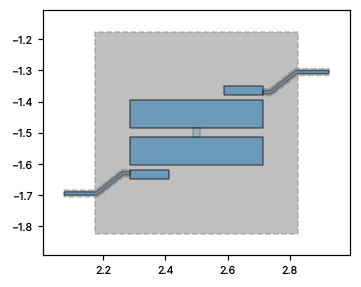

In [4]:
TransmonPocket(
    design,
    "Q1",
    options=dict(
        pos_x="-2.5mm",
        pos_y="-1.5mm",
        pad_width="425um",
        pocket_height="650um",
        connection_pads=dict(
            readout=dict(loc_W=-1, loc_H=1), coupler=dict(loc_W=1, loc_H=-1)
        ),
    ),
)
TransmonPocket(
    design,
    "Q2",
    options=dict(
        pos_x="2.5mm",
        pos_y="-1.5mm",
        pad_width="425um",
        pocket_height="650um",
        connection_pads=dict(
            readout=dict(loc_W=1, loc_H=1), coupler=dict(loc_W=-1, loc_H=-1)
        ),
    ),
)

## 2. Shared feedline + two readout resonators

One feedline, two coupled-line tees, two resonators of slightly different length (frequency-multiplexed readout).

In [5]:
CoupledLineTee(
    design,
    "clt1",
    options=dict(
        pos_x="-2.5mm",
        pos_y="1.5mm",
        coupling_length="350um",
        down_length="300um",
        fillet="90um",
        open_termination=False,
    ),
)
CoupledLineTee(
    design,
    "clt2",
    options=dict(
        pos_x="2.5mm",
        pos_y="1.5mm",
        coupling_length="350um",
        down_length="300um",
        fillet="90um",
        open_termination=False,
    ),
)
LaunchpadWirebond(
    design, "LP1", options=dict(pos_x="-6mm", pos_y="1.5mm", orientation="0")
)
LaunchpadWirebond(
    design, "LP2", options=dict(pos_x="6mm", pos_y="1.5mm", orientation="180")
)
feed("LP1", "tie", "clt1", "prime_start", "feed_L")
feed("clt1", "prime_end", "clt2", "prime_start", "feed_M")
feed("clt2", "prime_end", "LP2", "tie", "feed_R")
readout("clt1", "Q1", "read1", "7.0mm")
readout("clt2", "Q2", "read2", "7.2mm")

## 3. Qubit-qubit coupling bus

A meandered CPW between the two `coupler` pads sets the exchange coupling.

06:53PM 22s WARNING [check_lengths]: For path table, component=coupler_bus, key=trace has short segments that could cause issues with fillet. Values in (37-38)  are index(es) in shapely geometry.


06:53PM 22s WARNING [check_lengths]: For path table, component=coupler_bus, key=cut has short segments that could cause issues with fillet. Values in (37-38)  are index(es) in shapely geometry.


option,value,parsed,description
chip,'main','main',Chip holding the QComponent.
layer,'1',1.0,Manufacturing layer used for the QComponent.
pin_inputs,,,
start_pin,,,Component and pin string pair. Define which pin to start from
component,'Q1','Q1',"Name of component to start from, which has a pin"
pin,'coupler','coupler',Name of pin used for pin_start
end_pin,,,Component and pin string pair. Define which pin to start from
component,'Q2','Q2',"Name of component to end on, which has a pin"
pin,'coupler','coupler',Name of pin used for pin_end
fillet,'90um',0.09,

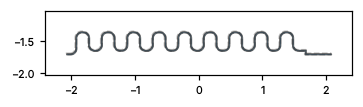

In [6]:
RouteMeander(
    design,
    "coupler_bus",
    options=dict(
        fillet="90um",
        total_length="8mm",
        lead=Dict(start_straight="150um", end_straight="150um"),
        meander=Dict(asymmetry="200um"),
        pin_inputs=Dict(
            start_pin=Dict(component="Q1", pin="coupler"),
            end_pin=Dict(component="Q2", pin="coupler"),
        ),
    ),
)

## 4. Visualize

## Next steps

- **Inspect** the design tree: `design.components.keys()` and `design.qgeometry.tables`.
- **Export GDS** for fabrication: `design.renderers.gds.export_to_gds('chip.gds')` (Quantum Metal uses the modern `gdstk` backend).
- **Simulate**: render to Ansys HFSS/Q3D (the validation gold standard) or to the open-source FEM path (Gmsh + Elmer today; AWS Palace on the roadmap) to extract eigenmodes, *Q*, and the capacitance matrix.
- **Tweak**: every dimension above is a parameter — change `total_length` to retune resonator frequencies, or `pos_x`/`pos_y` to relayout.

In [7]:
design.components.keys()

['Q1',
 'Q2',
 'clt1',
 'clt2',
 'LP1',
 'LP2',
 'feed_L',
 'feed_M',
 'feed_R',
 'read1',
 'read2',
 'coupler_bus']

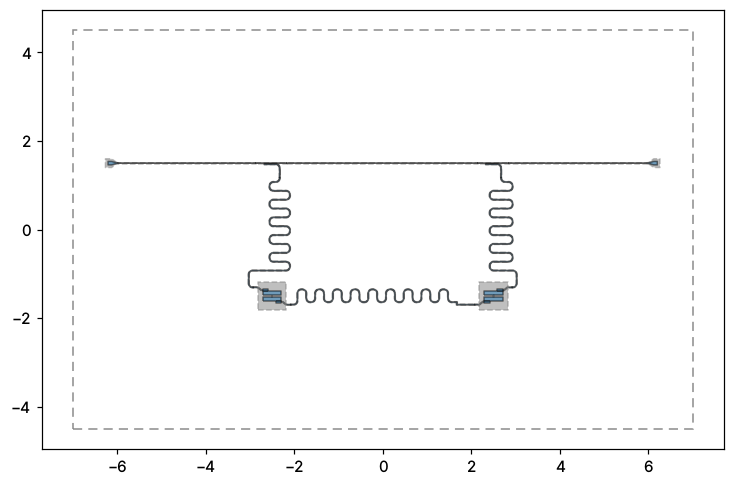

In [8]:
fig = qm.view(design)
qm.show_inline(fig)